<a href="https://colab.research.google.com/github/mokhivibes/ml_course_courseworks/blob/main/12_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1
Binomial E[X] va Var(X)



B(20, 0.3) taqsimoti uchun quyidagilarni bajaring:

E[X], Var(X) va sigma qiymatlarini formula orqali qo'lda hisoblang


In [ ]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme()
sns.set_style("whitegrid")


n, p = 20, 0.3

E_X = n * p
Var_X = n*p*(1-p)

print(f"E[X] = {E_X}")
print(f"Var(X) = {Var_X:.4f}")

scipy.stats.binom(20, 0.3) yordamida .mean(), .var(), .std() ni chiqaring


In [ ]:
dist = stats.binom(n, p)
var = dist.var()
mu = dist.mean()
sigma = dist.std()

In [ ]:
print(f"Variance: {var}")
print(f"Mean: {mu}")
print(f"Standard Deviation (σ): {sigma:.4f}")

In [ ]:
x = np.arange(0, n+1)

plt.figure(figsize=(10, 6))
plt.bar(x, dist.pmf(x), color='#2FC8D0', alpha=0.5)


plt.axvline(mu, color='#8E1531', linestyle='--', linewidth=2, label=f'Mean: {mu:.2f}')
plt.axvline(mu+sigma, color='#E66F1A', linestyle=':', linewidth=2, label=f'Mean + σ: {mu+sigma:.2f}')
plt.axvline(mu-sigma, color='#E66F1A', linestyle=':', linewidth=2, label=f'Mean - σ: {mu-sigma:.2f}')
plt.legend()
plt.title('Binomial Distribution')
plt.xlabel('X')
plt.ylabel('Probability')
plt.tight_layout()
plt.show()

Ikkita Normal Taqsimotni Taqqoslash



N(100, 10^2) va N(100, 25^2) taqsimotlarini bir grafikda ko'rsating:

Ikkala taqsimotni bitta plt.figure() ichida chizing (har biri uchun alohida rang)
Har biri uchun mu chizig'ini vertikal qizil chiziq sifatida qo'shing
plt.legend() bilan ikkalasini ajratib ko'rsating
Grafik ostiga: 'E[X] bir xil, lekin sigma katta bo'lsa grafik qanday o'zgaradi?' savoliga 1-2 gapda javob bering (# comment sifatida)

Savol: E[X] bir xil bo'lsa ham, sigma katta bo'lganda taqsimot qanday ko'rinadi? Grafik bu savolga javob berishi kerak.



In [ ]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
# Ikkala egri chiziqni bitta grafikda chizing
# legend va title qo'shing

dist1 = stats.norm(100, 10)
mu1 = dist1.mean()
sigma = dist1.std()
print(mu1)

dist2 = stats.norm(100, 25)
mu2 = dist2.mean()
sigma2 = dist2.std()
print(mu2)
x = np.linspace(0, 200, 500)


plt.figure(figsize=(10, 6))
plt.plot(x, dist1.pdf(x), color='#EF1598', label='N(100, 10^2)')
plt.axvline(mu1, color='red', linestyle=':', linewidth=2, label=f'Mean 1: {mu1}')


plt.plot(x, dist2.pdf(x), color='#6E34C1', label='N(100, 25^2)')
plt.axvline(mu2, color='black', linestyle='--', linewidth=2, label=f'Mean 2: {mu2}')

plt.legend()
plt.title('Normal Distributions')
plt.xlabel('X')
plt.ylabel('Probability')
plt.tight_layout()
plt.show()


# #Javob: Qancha sigma kattalashsa shuncha grafiik/distribution yoyiladi, natijada egri chiziq pastroq va kengroq bo'ladi, chunki yuza
# # (umumiy ehtimollik/some of p = 1) saqlanishi kerak.

3
Var(aX+b) = a^2 * Var(X) — Simulyatsiya Isboti



X = Binomial(10, 0.4) asosida quyidagi isbotni bajaring:


Y = 3*X + 7 deb oling


1-usul: Var(Y) ni to'g'ridan-to'g'ri formuladan hisoblang: a^2 * Var(X)

2-usul: np.random (size=100_000) yordamida simulyatsiya orqali Var(Y) ni hisoblang

Ikkala natijani print() bilan chiqarib, farqini ko'rsating

Bonus: Nima uchun Var(aX+b) da b ta'sir qilmaydi? Qisqacha izoh yozing (# comment)


In [ ]:
n = 10
p=0.4
a, b = 3, 7

E_X = n * p
Var_X = n*p*(1-p)
Var_Y = a**2 * Var_X
print(Var_X)
print(f"Without simulation variance is: {Var_Y:.2f}")

In [ ]:
n = 10
p=0.4
np.random.seed(42)
X = np.random.binomial(n, p, size=100_000)
Y = a*X + b

var_y= Y.var()
print(f"With simulation variance is: {var_y:.2f}")

JAVOB: b — barcha qiymatlarni bir xil miqdorga siljitadi, shuning uchun o'rtacha ham siljiydi (E[X]+b) va ta'sir qiladi. Lekin qiymatlar orasidagi farq o'zgarmaydi, shuning uchun Var(X) o'zgarmaydi.

4
Noto'g'ri Zar — PMF Tekshiruvi



Quyidagi PMF berilgan — lekin u to'g'rimi? Tekshiring va tuzating:

x
1
2
3
4
5
P(X=x)
0.10
0.20
0.30
0.25
0.20


sum(probs) ni hisoblang — PMF to'g'rimi?
Agar yig'indi 1 ga teng bo'lmasa, P(X=5) ni tuzatib, to'g'ri PMF hosil qiling
To'g'rilangan PMF bar grafigini chizing va E[X] ni hisoblang

Eslatma: PMF ning birinchi sharti — barcha ehtimolliklar yig'indisi = 1. Buni har doim tekshiring.



In [ ]:
x_vals = np.array([1, 2, 3, 4, 5])
probs = np.array([0.10, 0.20, 0.30, 0.25, 0.20])

# 1. Yig'indini tekshiring


print(f"Yig'indi: {np.sum(probs)}")  # 1 bo'lishi kerak

#sum(probs) ni hisoblang — PMF to'g'rimi?
#JAVOB: Yo'q

difference = np.sum(probs) - 1.0
probs[4]-=difference
print(f"To'g'irlanga probs qiymatlardan so'ng, PMF: {np.sum(probs)} ga teng")


Yig'indi: 1.05
To'g'irlanga probs qiymatlardan so'ng, PMF: 1.0 ga teng


In [ ]:
#To'g'rilangan PMF bar grafigini chizing va E[X] ni hisoblang
# 3. E[X] ni hisoblang va grafik chizing
E_X = np.sum(x_vals * probs)
print(f"E[X] = {E_X:.2f}")

E[X] = 3.15


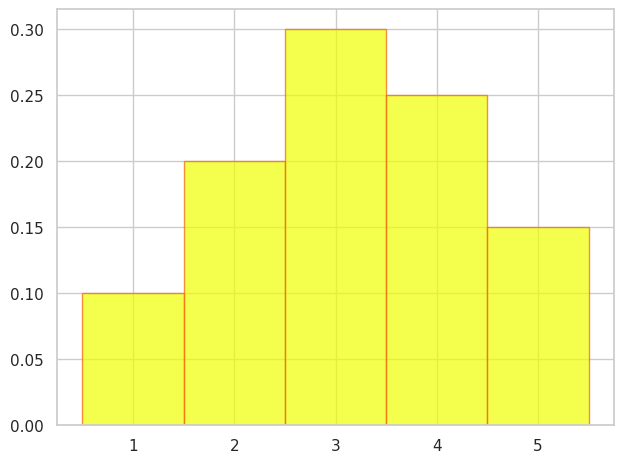

In [ ]:

plt.bar(x_vals, probs, width=1, color='#EEFF00', alpha=0.7, ec ='#F4610B' )
plt.tight_layout()
plt.show()

5
Poisson Taqsimoti — Mijozlar Oqimi



Do'konga kunda o'rtacha 5 ta mijoz keladi. X ~ Poisson(lambda=5).

E[X] va Var(X) ni formuladan hisoblang (Poisson uchun ikkalasi ham lambda ga teng)
P(X = 0) — hech kim kelmasin ehtimolligini toping
P(X >= 8) — 8 va undan ko'p mijoz kelish ehtimolligini toping
PMF grafigini x = 0 dan 15 gacha chizing, E[X] = lambda chizig'ini ko'rsating

Muhim: Poisson da E[X] = Var(X) = lambda — bu uning eng noyob xossasi!



E[X]: 5.0
Var(X): 5.0
P(X=0)(Hech kim kelmasin) = 0.0067
P(X>=8) = 0.1334


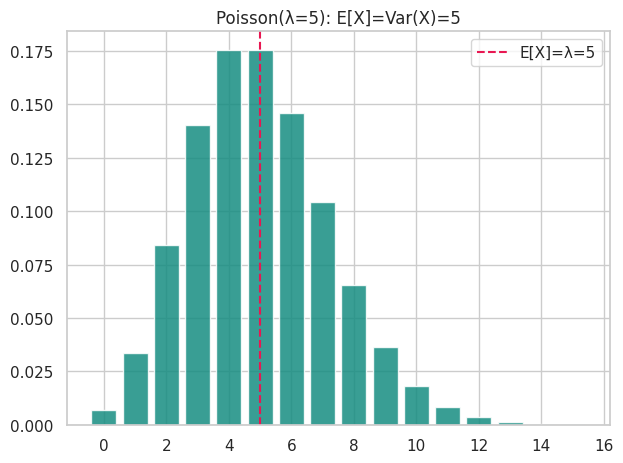

In [ ]:

lam = 5
dist = stats.poisson(lam)


# E[X], Var(X)
print(f"E[X]: {dist.mean()}")
print(f"Var(X): {dist.var()}")


print(f"P(X=0)(Hech kim kelmasin) = {dist.pmf(0):.4f}")
some =  1-dist.cdf(7)
print(f"P(X>=8) = {some:.4f}")

# Grafik: x = np.arange(0, 16)
x = np.arange(0, 16)
plt.bar(x, dist.pmf(x), color="#168D81", alpha=0.85)
plt.axvline(lam, color="#E81752", linestyle="--", label=f"E[X]=λ={lam}")
plt.title(f"Poisson(λ={lam}): E[X]=Var(X)={lam}")
plt.legend(); plt.tight_layout(); plt.show()

6
E[X] Chiziqlilik Xossasi
O'rta


X ~ Binomial(15, 0.4). Quyidagi ifodalarni IKKALA usul bilan hisoblang:

Ifoda
Formuladan (qo'lda)
Simulyatsiya
E[X]
n * p = ?
X_sim.mean()
E[4X]
4 * E[X] = ?
(4*X_sim).mean()
E[4X + 10]
4*E[X] + 10 = ?
(4*X_sim+10).mean()
E[X^2]
Var(X) + (E[X])^2 = ?
(X_sim**2).mean()


Barcha 4 natijani jadval ko'rinishida print() qiling
E[X^2] vs (E[X])^2 farqini izohlang (# comment sifatida)

Eslatma: E[X^2] != (E[X])^2 — bu juda muhim farq! Dispersiyaning asosi shu yerda.



In [ ]:
import numpy as np
from scipy import stats
import pandas as pd
n, p = 15, 0.4
np.random.seed(42)
X_sim = np.random.binomial(n, p, size=100_000)

# Formuladan va simulyatsiyadan solishtiring
E_X = n * p
E_4X = 4 * E_X
E_4X_plus_10 = 4 * E_X + 10
E_X2 = np.var(X_sim) + E_X**2  # Var + (E[X])^2

df= pd.DataFrame({'E_X': [E_X], 'E_4X': [E_4X] , 'E_4X_plus_10': [E_4X_plus_10], 'E_X2':[E_X2] })
df

,E_X,E_4X,E_4X_plus_10,E_X2
0,6.0,24.0,34.0,39.581175


7
Dispersiya — Ikkita O'yinchi Taqqoslash
O'rta


Dars 12 da ko'rgan ikki o'yinchini Python bilan tahlil qiling:



Kun 1
Kun 2
Kun 3
Kun 4
Kun 5
O'yinchi A
48k
50k
52k
49k
51k
O'yinchi B
10k
20k
90k
80k
50k


Har ikki o'yinchi uchun mean(), var(), std() hisoblang
Ikkala o'yinchining daromadini bitta subplot (1x2) bilan chizing
Qaysi o'yinchi barqarorroq? Nima uchun? (# comment sifatida 1-2 gap)

Savol: Agar siz menejer bo'lsangiz, qaysi o'yinchini tanlagan bo'lar edingiz? Dispersiya bu qarorga qanday ta'sir qiladi?



50.0, 2.0, 1.4142


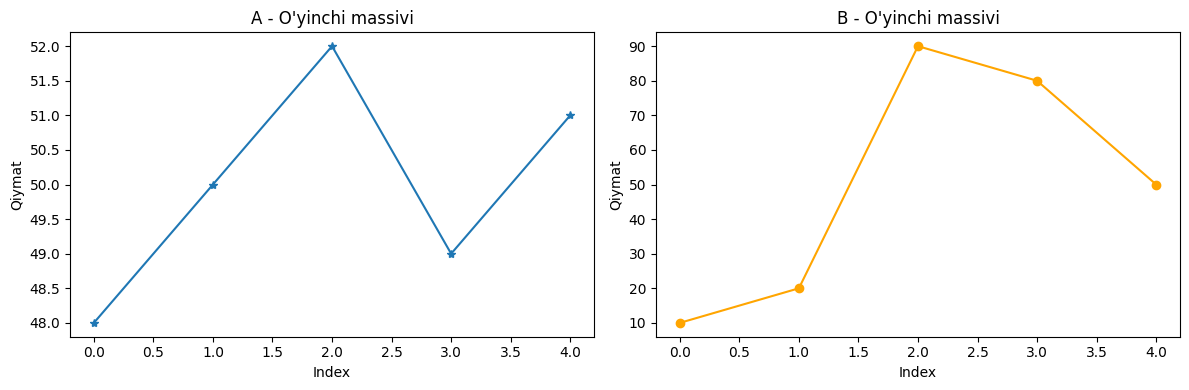

In [9]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([48, 50, 52, 49, 51])  # ming so'm
B = np.array([10, 20, 90, 80, 50])

# mean, var, std
# subplot bilan ikki grafik
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))


print(f"{A.mean()}, { A.var()}, {A.std():.4f}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(A, marker='*')
ax1.set_title('A - O\'yinchi massivi')
ax1.set_xlabel('Index')
ax1.set_ylabel('Qiymat')

ax2.plot(B, marker='o', color='orange')
ax2.set_title('B - O\'yinchi massivi')
ax2.set_xlabel('Index')
ax2.set_ylabel('Qiymat')

plt.tight_layout()
plt.show()


8
CDF — Taqsimot Funksiyasi
Qiyin


X ~ Normal(mu=170, sigma=10) — talabalar bo'yi. CDF yordamida ehtimolliklarni toping:

P(X <= 160) — 160 sm dan past bo'y ehtimolligi
P(160 < X <= 180) — 160 va 180 sm orasida bo'lish ehtimolligi
P(X > 185) — 185 sm dan baland bo'y ehtimolligi
Uchta natijani print() qiling va yig'indi mantiqli emasligini tushuntiring (ular qo'shilmaydi, chunki oraliqlar turli)
Bonus: 68-95-99.7 qoidasini tekshiring — P(mu-sigma < X < mu+sigma) ≈ 0.68 ekanligini isbotlang

Eslatma: dist.cdf(x) — x gacha bo'lgan ehtimollik. P(a < X <= b) = cdf(b) - cdf(a).



In [ ]:
from scipy import stats

mu, sigma = 170, 10
dist = stats.norm(mu, sigma)

# P(X <= 160)
p1 = dist.cdf(160)

# P(160 < X <= 180)
p2 = dist.cdf(180) - dist.cdf(160)

# P(X > 185)
p3 = 1 - dist.cdf(185)  # yoki dist.sf(185)
